# Correlation Analysis Per Video: MoLab Features vs IRAF SAT (n=10)

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import os

MOLAB_DIR     = Path('../data/processed/molab_cropped')
FEATURES_DIR  = '../data/processed/features/'
OUT_DIR     = '../data/processed/features/molab/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)

KORS_PATH   = '../data/original/Forts_IRAF_SAT_Kors _Gemensamt.xlsx'
RAK_PATH    = '../data/original/Final_IRAF_SAT_Rak_Bedömare sep och gemensamt.xlsx'

TIME_DICT = {
    '0028': (9.90, 10.40, 10.50, 11.12, 11.19, 11.77),
    '0030': (5.80, 6.25, 6.32,  6.70,  6.76,  7.63),
    '0045': (6.54, 6.70, 6.70,  7.29,  7.45,  7.98),
    '0047': (7.03, 7.41, 7.49,  7.79,  7.97,  8.91),
    '0059': (6.65, 6.88, 6.90,  7.96,  8.19,  9.11),
    '0061': (7.00, 7.40, 7.45,  8.10,  8.20,  9.00),
    '0074': (6.07, 6.33, 6.35,  6.71,  6.90,  7.27),
    '0076': (5.20, 5.80, 5.90,  6.30,  6.40,  7.30),
    '0091': (6.39, 6.55, 6.60,  7.03,  7.18,  7.61),
    '0093': (5.86, 5.92, 6.20,  6.65,  6.92,  7.67),
}

In [2]:
def parse_iraf_per_video(xl, sheet_name, phase_map, fp_videos=None):
    """
    phase_map: list of (header_prefix, phase_label | None).
    Rows whose stripped col-0 starts with a prefix are section headers;
    subsequent items get that phase label. None means skip items in that section.
    """
    raw = xl.parse(sheet_name, header=None)
    col0 = raw.iloc[:, 0].fillna('').astype(str).str.strip()

    is_block = (col0.str.contains('Film Nr', na=False) |
                col0.str.contains(', [Vv]ideo ', na=False, regex=True))
    if fp_videos is not None:
        is_block = is_block | col0.str.match(r'Fp\d+_', na=False)
    block_rows = raw.index[is_block].tolist()
    block_rows.append(len(raw))

    def get_video(text):
        if 'Film Nr' in text:
            return text.split('Film Nr:')[1].strip().split()[0].zfill(3)
        elif ', video ' in text.lower():
            return text.lower().split(', video ')[1].strip().split()[0].zfill(3)
        elif fp_videos is not None:
            m = re.match(r'Fp(\d+)_', text)
            if m:
                idx = int(m.group(1)) - 1
                return fp_videos[idx] if idx < len(fp_videos) else None
        return None

    _UNSET = object()

    def match_phase(text):
        for prefix, label in phase_map:
            if text.startswith(prefix):
                return label  # may be None (skip section)
        return _UNSET  # not a header row

    records = []
    for i, start in enumerate(block_rows[:-1]):
        video = get_video(col0.iloc[start])
        if video is None:
            continue
        current_phase = _UNSET
        for idx in range(start, block_rows[i + 1]):
            cell = col0.iloc[idx]
            result = match_phase(cell)
            if result is not _UNSET:
                current_phase = result
                continue
            if current_phase is None or current_phase is _UNSET:
                continue
            r = raw.iloc[idx]
            gem = r[12]
            weight = pd.to_numeric(r[1], errors='coerce')
            if pd.notna(weight) and pd.notna(gem):
                try:
                    val = float(gem)
                    records.append({'video': video, 'phase': current_phase,
                                    'weight': weight, 'avvikelse': val})
                except (ValueError, TypeError):
                    pass
    return pd.DataFrame(records)


UP_PHASE_MAP = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),     # single item, skipped
    ('Rörelseutförande', None),     # general item before sub-phases, skipped
    ('Förberedelsefas',  'forb'),
    ('Uppresningsfas',   'uppr'),
]

kors_xl = pd.ExcelFile(KORS_PATH)
rak_xl  = pd.ExcelFile(RAK_PATH)
kors_df = parse_iraf_per_video(kors_xl, 'Sittande till stående', UP_PHASE_MAP)
rak_df  = parse_iraf_per_video(rak_xl,  'Sittande till stående', UP_PHASE_MAP)
iraf_raw = pd.concat([kors_df, rak_df], ignore_index=True)
iraf_raw = iraf_raw.assign(w=iraf_raw['avvikelse'] * iraf_raw['weight'])

iraf_pv = (iraf_raw.groupby(['video', 'phase'])
           .apply(lambda g: g['w'].sum() / g['weight'].sum())
           .unstack().reset_index())
iraf_pv.columns.name = None
iraf_pv.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv.columns[1:]]

phase_score_cols = [c for c in iraf_pv.columns if c != 'video']
iraf_pv['iraf_total'] = iraf_pv[phase_score_cols].mean(axis=1)

iraf_pv

,video,iraf_forb,iraf_uppr,iraf_utg,iraf_total
0,028,0.833333,0.875000,0.870370,0.859568
1,030,0.333333,0.250000,0.055556,0.212963
2,045,1.000000,1.500000,1.407407,1.302469
3,047,0.833333,0.750000,1.523810,1.035714
4,059,0.833333,0.833333,0.937500,0.868056
5,061,0.833333,0.750000,0.650000,0.744444
6,074,0.944444,1.125000,1.047619,1.039021
7,076,0.500000,1.500000,0.555556,0.851852
8,091,0.583333,1.250000,1.460317,1.097884
9,093,0.500000,0.625000,0.722222,0.615741


In [3]:
def get_phase(df, t_start, t_end):
    return df[(df['video_time'] >= t_start) & (df['video_time'] <= t_end)]

def rms(x): return np.sqrt(np.mean(x**2))

def extract_utgångsposition(df, t0, t1):
    p = get_phase(df, t0, t1)
    lk, rk = p['JointAngle/L_knee_X'], p['JointAngle/R_knee_X']
    return {
        'mean_L_knee_flexion':  lk.mean(),
        'mean_R_knee_flexion':  rk.mean(),
        'delta_knee_asymmetry': abs(lk.mean() - rk.mean()),
        'mean_L_hip_flexion':   p['JointAngle/L_hip_X'].mean(),
        'mean_R_hip_flexion':   p['JointAngle/R_hip_X'].mean(),
        'mean_pelvis_tilt':     p['JointAngle/pelvis_X'].mean(),
        'mean_pelvis_lateral':  p['JointAngle/pelvis_Y'].abs().mean(),
    }

def extract_rörelsestart(df, t1, t5):
    p = get_phase(df, t1, t5)
    pelvis_x, gyro_y = p['JointAngle/pelvis_X'], p['SegmentGyro/pelvis_Y']
    return {
        'initial_pelvis_tilt': pelvis_x.iloc[0] if len(pelvis_x) else np.nan,
        'max_pelvis_tilt':     pelvis_x.max(),
        'delta_pelvis_tilt':   pelvis_x.max() - pelvis_x.min(),
        'peak_pelvis_gyro':    gyro_y.abs().max(),
        'mean_pelvis_gyro':    gyro_y.abs().mean(),
        'hip_flexion_range':   ((p['JointAngle/L_hip_X'].max() - p['JointAngle/L_hip_X'].min()) +
                                (p['JointAngle/R_hip_X'].max() - p['JointAngle/R_hip_X'].min())) / 2,
        'rms_pelvis_acc':      rms(p['SegmentAcc/pelvis_Y'].values),
    }

def extract_rörelseutförande(df, t2, t3, t4, t5):
    forb, uppr = get_phase(df, t2, t3), get_phase(df, t4, t5)
    lk_up, rk_up = uppr['JointAngle/L_knee_X'], uppr['JointAngle/R_knee_X']
    return {
        'forb_delta_pelvis_tilt':    forb['JointAngle/pelvis_X'].max() - forb['JointAngle/pelvis_X'].min(),
        'forb_peak_pelvis_gyro':     forb['SegmentGyro/pelvis_Y'].abs().max(),
        'forb_rms_pelvis_acc':       rms(forb['SegmentAcc/pelvis_Y'].values),
        'uppr_total_knee_extension': ((lk_up.max() - lk_up.min()) + (rk_up.max() - rk_up.min())) / 2,
        'uppr_peak_shank_gyro':      max(uppr['SegmentGyro/L_shank_Y'].abs().max(),
                                         uppr['SegmentGyro/R_shank_Y'].abs().max()),
        'uppr_total_hip_extension':  ((uppr['JointAngle/L_hip_X'].max() - uppr['JointAngle/L_hip_X'].min()) +
                                      (uppr['JointAngle/R_hip_X'].max() - uppr['JointAngle/R_hip_X'].min())) / 2,
    }


In [4]:
feat_utg  = pd.read_csv(FEATURES_DIR + 'molab_utgångsposition.csv')
feat_forb = pd.read_csv(FEATURES_DIR + 'molab_förberedelsefas.csv')
feat_uppr = pd.read_csv(FEATURES_DIR + 'molab_uppresningsfas.csv')
for df in [feat_utg, feat_forb, feat_uppr]:
    df['video'] = df['video'].astype(str).str.zfill(3)

merged_utg  = feat_utg.merge( iraf_pv[['video', 'iraf_utg']].rename( columns={'iraf_utg':  'iraf_score'}), on='video')
merged_forb = feat_forb.merge(iraf_pv[['video', 'iraf_forb']].rename(columns={'iraf_forb': 'iraf_score'}), on='video')
merged_uppr = feat_uppr.merge(iraf_pv[['video', 'iraf_uppr']].rename(columns={'iraf_uppr': 'iraf_score'}), on='video')
print(f'n per phase   utg:{len(merged_utg)}, forb:{len(merged_forb)}, uppr:{len(merged_uppr)}')

n per phase   utg:10, forb:10, uppr:10


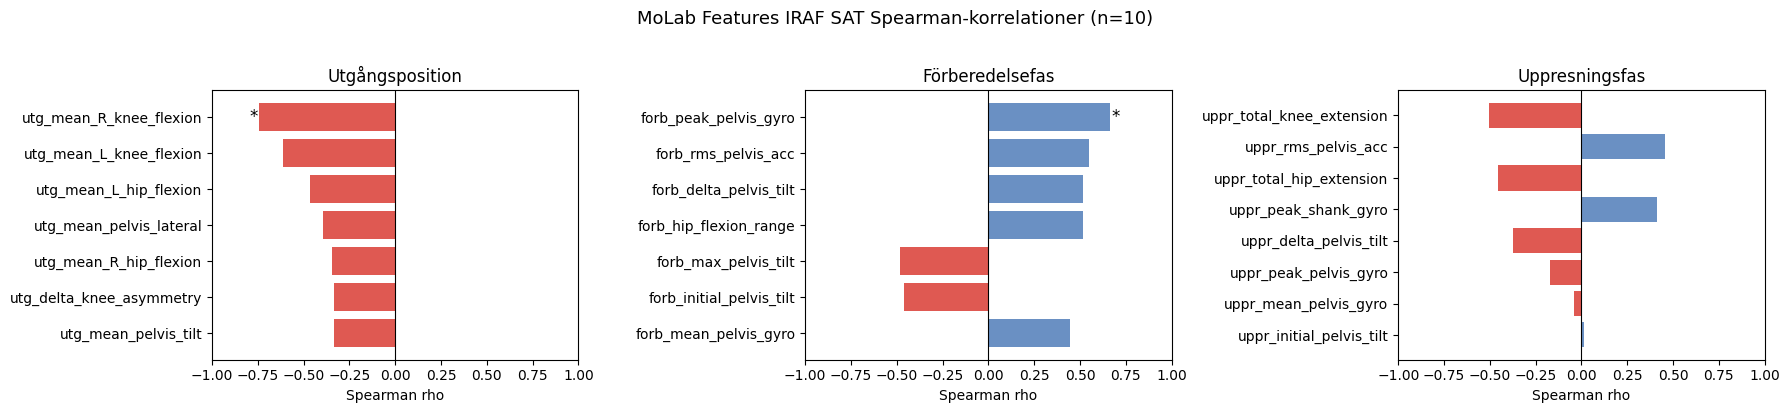

In [5]:
def spearman(df):
    result = pd.DataFrame([
        {'feature': c, 'rho': stats.spearmanr(df[c], df['iraf_score'])[0],
                       'p':   stats.spearmanr(df[c], df['iraf_score'])[1]}
        for c in df.columns if c not in ['video', 'iraf_score']
        if df[[c, 'iraf_score']].dropna().__len__() >= 3
    ])
    return result.sort_values('rho', key=abs, ascending=False) if len(result) else result

corr_utg  = spearman(merged_utg)
corr_forb = spearman(merged_forb)
corr_uppr = spearman(merged_uppr)

corr_utg.to_csv(OUT_DIR  + 'corr_utgångsposition.csv', index=False)
corr_forb.to_csv(OUT_DIR + 'corr_förberedelsefas.csv', index=False)
corr_uppr.to_csv(OUT_DIR + 'corr_uppresningsfas.csv',  index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, corr, title in zip(axes, [corr_utg, corr_forb, corr_uppr],
                                  ['Utgångsposition', 'Förberedelsefas', 'Uppresningsfas']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('MoLab Features IRAF SAT Spearman-korrelationer (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

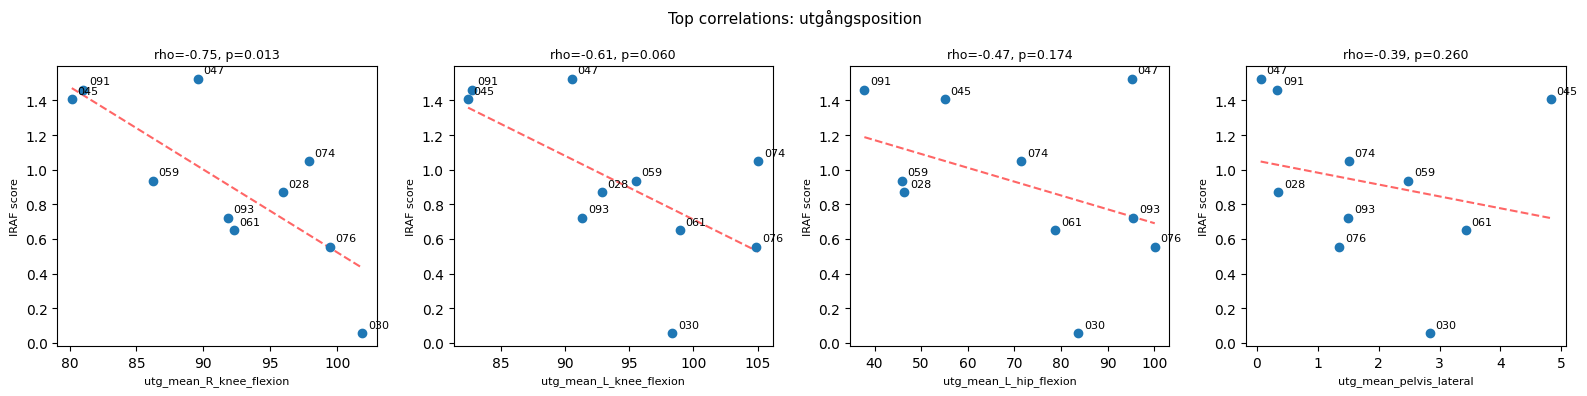

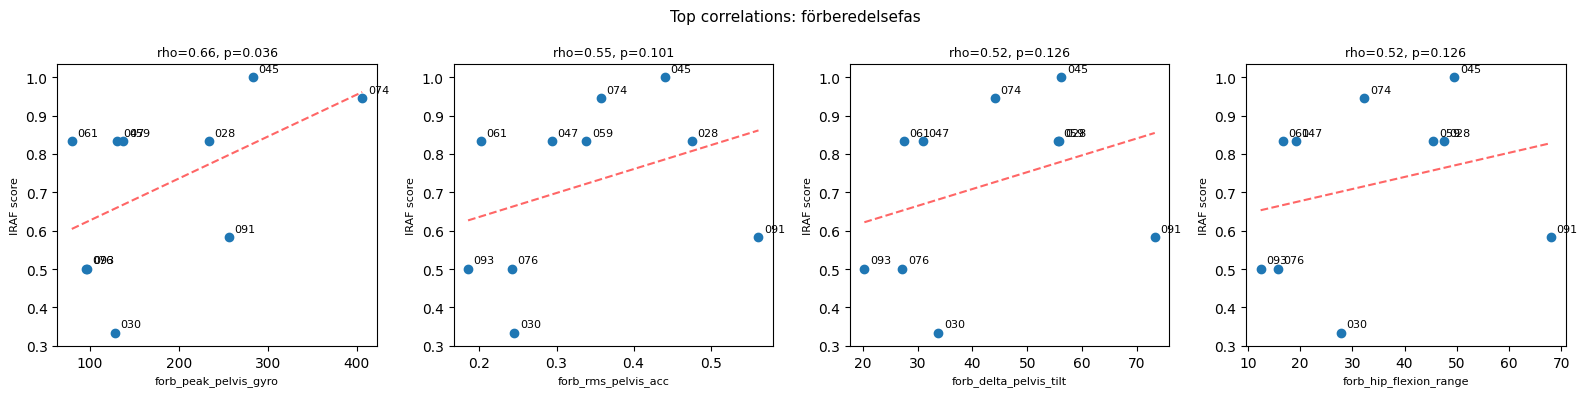

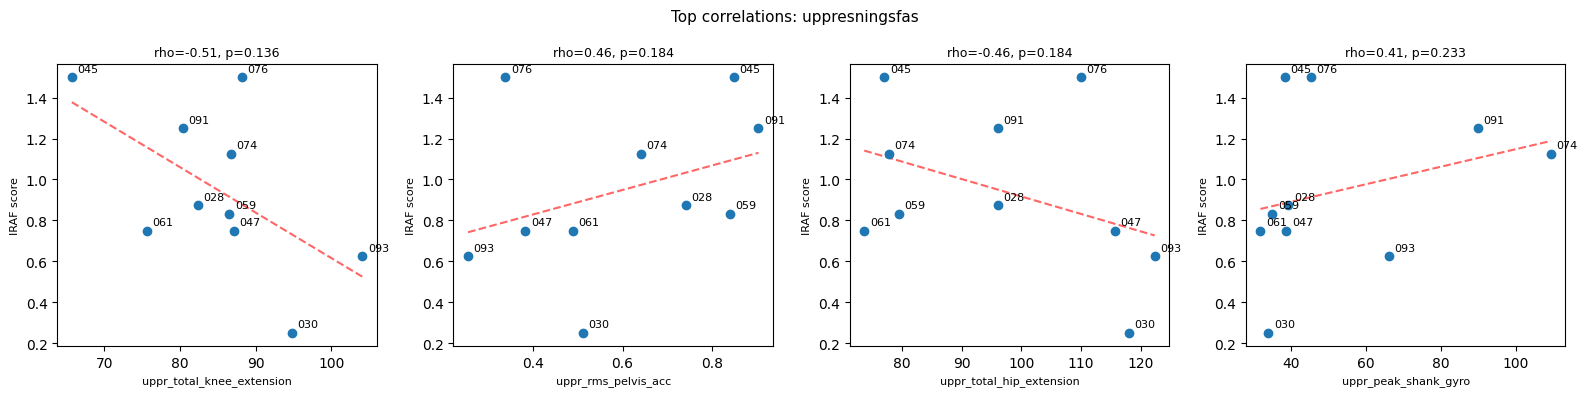

In [6]:
def plot_top_scatters(merged_df, corr_df, phase_name, n_top=4, out_dir=None):
    top = corr_df.head(n_top)
    fig, axes = plt.subplots(1, len(top), figsize=(4*len(top), 4))
    if len(top) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top.iterrows()):
        fc = row['feature']
        vals = merged_df[['video', fc, 'iraf_score']].dropna()
        ax.scatter(vals[fc], vals['iraf_score'], zorder=3)
        for _, r in vals.iterrows():
            ax.annotate(r['video'], (r[fc], r['iraf_score']),
                        textcoords='offset points', xytext=(4, 4), fontsize=8)
        m, b = np.polyfit(vals[fc], vals['iraf_score'], 1)
        xr = np.linspace(vals[fc].min(), vals[fc].max(), 50)
        ax.plot(xr, m*xr+b, 'r--', alpha=0.6)
        ax.set_xlabel(fc, fontsize=8)
        ax.set_ylabel('IRAF score', fontsize=8)
        ax.set_title(f'rho={row["rho"]:.2f}, p={row["p"]:.3f}', fontsize=9)
    if out_dir is None:
        out_dir = OUT_DIR
    fig.suptitle(f'Top correlations: {phase_name}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{out_dir}molab_scatter_{phase_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_top_scatters(merged_utg,  corr_utg,  'utgångsposition')
plot_top_scatters(merged_forb, corr_forb, 'förberedelsefas')
plot_top_scatters(merged_uppr, corr_uppr, 'uppresningsfas')

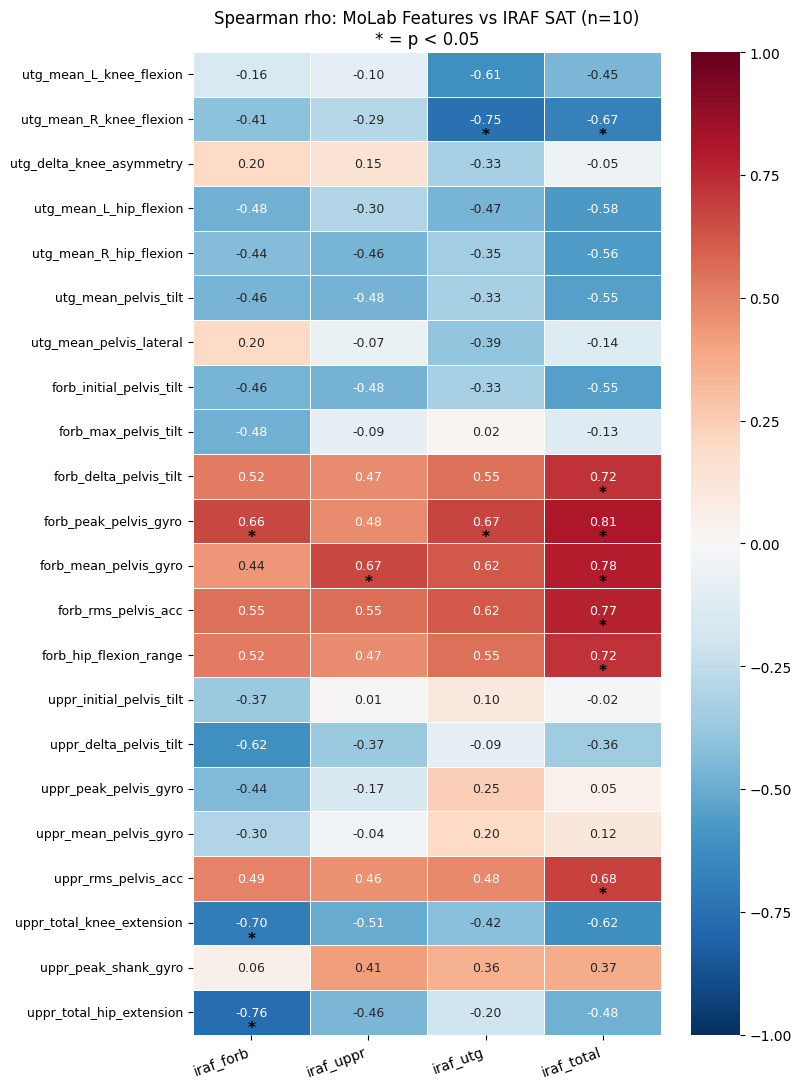

In [7]:
all_feats = feat_utg.merge(feat_forb, on='video', how='outer').merge(feat_uppr, on='video', how='outer')
merged_all = all_feats.merge(iraf_pv, on='video')

feat_cols = [c for c in all_feats.columns if c != 'video']
iraf_cols = [c for c in iraf_pv.columns if c != 'video']

rho_mat = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
p_mat   = pd.DataFrame(index=feat_cols, columns=iraf_cols, dtype=float)
for fc in feat_cols:
    for ic in iraf_cols:
        vals = merged_all[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat.loc[fc, ic], p_mat.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols) * 0.5)))
sns.heatmap(rho_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat.isna(), annot_kws={'size': 9})
for i, fc in enumerate(feat_cols):
    for j, ic in enumerate(iraf_cols):
        if pd.notna(p_mat.loc[fc, ic]) and p_mat.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: MoLab Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + 'molab_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
corr_results = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat.loc[fc, ic], 'p_value': p_mat.loc[fc, ic]}
    for fc in feat_cols for ic in iraf_cols
    if pd.notna(rho_mat.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results.to_csv(OUT_DIR + 'molab_correlation_results.csv', index=False)
print(f'{len(corr_results)} correlations saved')
corr_results.head(10)


88 correlations saved


,feature,iraf_score,spearman_rho,p_value
43,forb_peak_pelvis_gyro,iraf_total,0.806061,0.004862
47,forb_mean_pelvis_gyro,iraf_total,0.781818,0.007547
51,forb_rms_pelvis_acc,iraf_total,0.769697,0.009222
84,uppr_total_hip_extension,iraf_forb,-0.763167,0.010225
6,utg_mean_R_knee_flexion,iraf_utg,-0.745455,0.013330
55,forb_hip_flexion_range,iraf_total,0.721212,0.018573
39,forb_delta_pelvis_tilt,iraf_total,0.721212,0.018573
76,uppr_total_knee_extension,iraf_forb,-0.695467,0.025546
75,uppr_rms_pelvis_acc,iraf_total,0.684848,0.028883
7,utg_mean_R_knee_flexion,iraf_total,-0.672727,0.033041


## Stående till sittande (Stand-to-Sit)

In [9]:
DOWN_PHASE_MAP = [
    ('Utgångsposition',  'utg'),
    ('Rörelsestart',     None),     # single item, skipped
    ('Rörelseutförande', None),     # general item before sub-phases, skipped
    ('Fas 1',            'ned'),
    ('Fas 2',            'bak'),
]

DOWN_FEATURES_DIR_M = '../data/processed/features_down/'
DOWN_OUT_DIR_MOLAB  = '../data/processed/features_down/molab/per_video/'
os.makedirs(DOWN_OUT_DIR_MOLAB, exist_ok=True)
RAK_DOWN_FP_VIDEOS  = ['030', '047', '061', '076', '093']

kors_df_d = parse_iraf_per_video(kors_xl, 'Stående till sittande', DOWN_PHASE_MAP)
rak_df_d  = parse_iraf_per_video(rak_xl,  'Stående till sittande', DOWN_PHASE_MAP, fp_videos=RAK_DOWN_FP_VIDEOS)
iraf_raw_d = pd.concat([kors_df_d, rak_df_d], ignore_index=True)
iraf_raw_d = iraf_raw_d.assign(w=iraf_raw_d['avvikelse'] * iraf_raw_d['weight'])

iraf_pv_d = (iraf_raw_d.groupby(['video', 'phase'])
             .apply(lambda g: g['w'].sum() / g['weight'].sum())
             .unstack().reset_index())
iraf_pv_d.columns.name = None
iraf_pv_d.columns = ['video'] + [f'iraf_{c}' for c in iraf_pv_d.columns[1:]]

phase_score_cols_d = [c for c in iraf_pv_d.columns if c != 'video']
iraf_pv_d['iraf_total'] = iraf_pv_d[phase_score_cols_d].mean(axis=1)

iraf_pv_d

,video,iraf_bak,iraf_ned,iraf_utg,iraf_total
0,028,2.000000,0.000000,0.428571,0.809524
1,030,0.000000,0.000000,0.000000,0.000000
2,045,1.866667,0.363636,1.125000,1.118434
3,047,0.714286,0.454545,0.600000,0.589610
4,059,1.333333,0.083333,0.666667,0.694444
5,061,0.600000,0.375000,0.733333,0.569444
6,074,1.466667,0.208333,0.444444,0.706481
7,076,0.600000,0.375000,1.133333,0.702778
8,091,1.333333,0.208333,0.555556,0.699074
9,093,1.000000,0.727273,1.000000,0.909091


In [10]:
feat_utg_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_utgångsposition.csv')
feat_ned_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_nedåtgående.csv')
feat_bak_d = pd.read_csv(DOWN_FEATURES_DIR_M + 'down_molab_bakåtgående.csv')
for df in [feat_utg_d, feat_ned_d, feat_bak_d]:
    df['video'] = df['video'].astype(str).str.zfill(3)

merged_utg_d = feat_utg_d.merge(iraf_pv_d[['video', 'iraf_utg']].rename(columns={'iraf_utg': 'iraf_score'}), on='video')
merged_ned_d = feat_ned_d.merge(iraf_pv_d[['video', 'iraf_ned']].rename(columns={'iraf_ned': 'iraf_score'}), on='video')
merged_bak_d = feat_bak_d.merge(iraf_pv_d[['video', 'iraf_bak']].rename(columns={'iraf_bak': 'iraf_score'}), on='video')
print(f'n per phase   utg:{len(merged_utg_d)}, ned:{len(merged_ned_d)}, bak:{len(merged_bak_d)}')

n per phase   utg:10, ned:10, bak:10


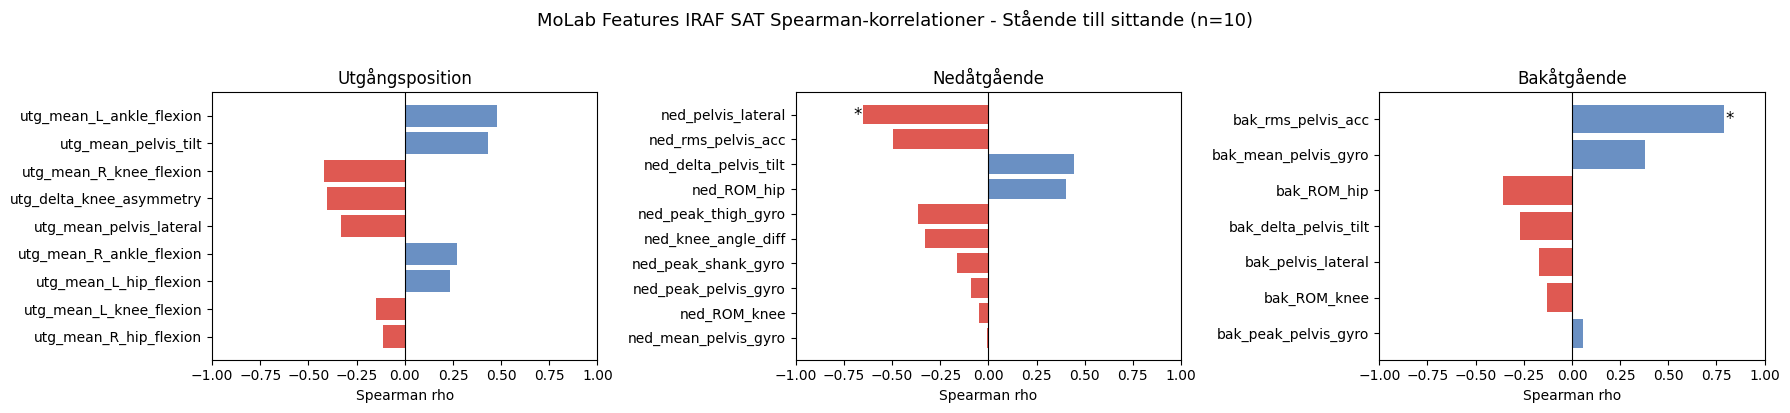

In [11]:
corr_utg_d = spearman(merged_utg_d)
corr_ned_d = spearman(merged_ned_d)
corr_bak_d = spearman(merged_bak_d)

corr_utg_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_utgångsposition.csv', index=False)
corr_ned_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_nedåtgående.csv',     index=False)
corr_bak_d.to_csv(DOWN_OUT_DIR_MOLAB + 'corr_bakåtgående.csv',     index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, corr, title in zip(axes, [corr_utg_d, corr_ned_d, corr_bak_d],
                                  ['Utgångsposition', 'Nedåtgående', 'Bakåtgående']):
    c = corr.set_index('feature')
    ax.barh(c.index, c['rho'], color=['#d73027' if r < 0 else '#4575b4' for r in c['rho']], alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(c.iterrows()):
        if row['p'] < 0.05:
            ax.text(row['rho'] + (0.03 if row['rho'] >= 0 else -0.03), i, '*', ha='center', va='center', fontsize=12)
plt.suptitle('MoLab Features IRAF SAT Spearman-korrelationer - Stående till sittande (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_MOLAB + 'molab_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

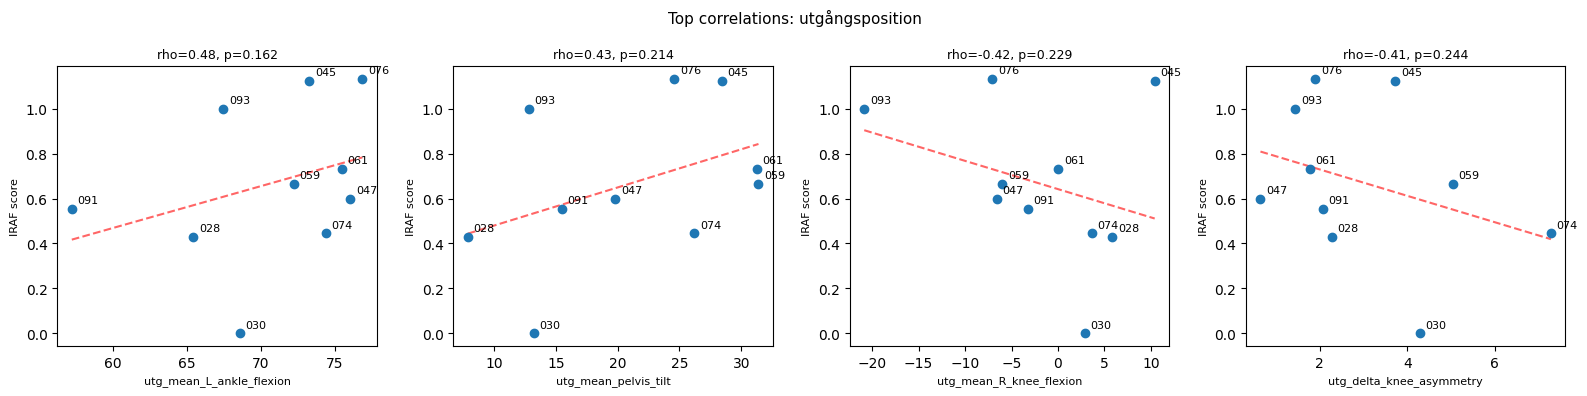

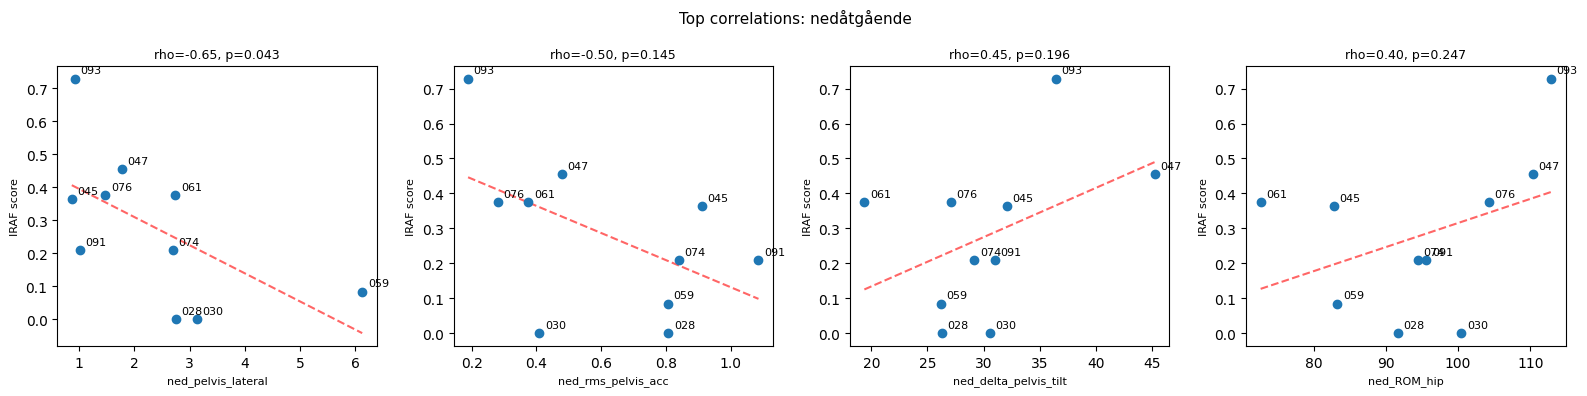

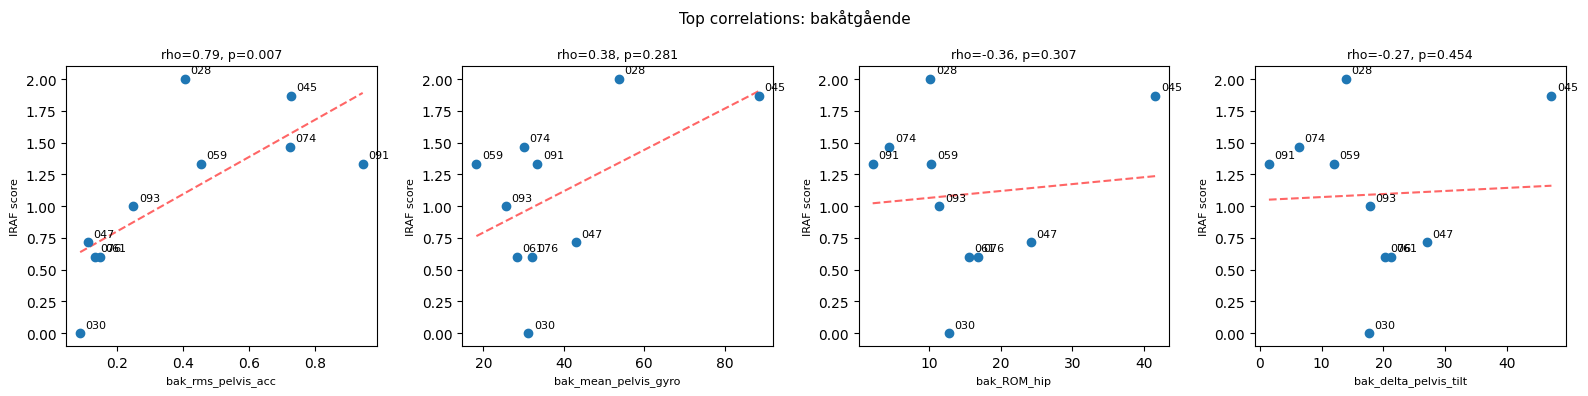

In [12]:
plot_top_scatters(merged_utg_d, corr_utg_d, 'utgångsposition', out_dir=DOWN_OUT_DIR_MOLAB)
plot_top_scatters(merged_ned_d, corr_ned_d, 'nedåtgående',     out_dir=DOWN_OUT_DIR_MOLAB)
plot_top_scatters(merged_bak_d, corr_bak_d, 'bakåtgående',     out_dir=DOWN_OUT_DIR_MOLAB)

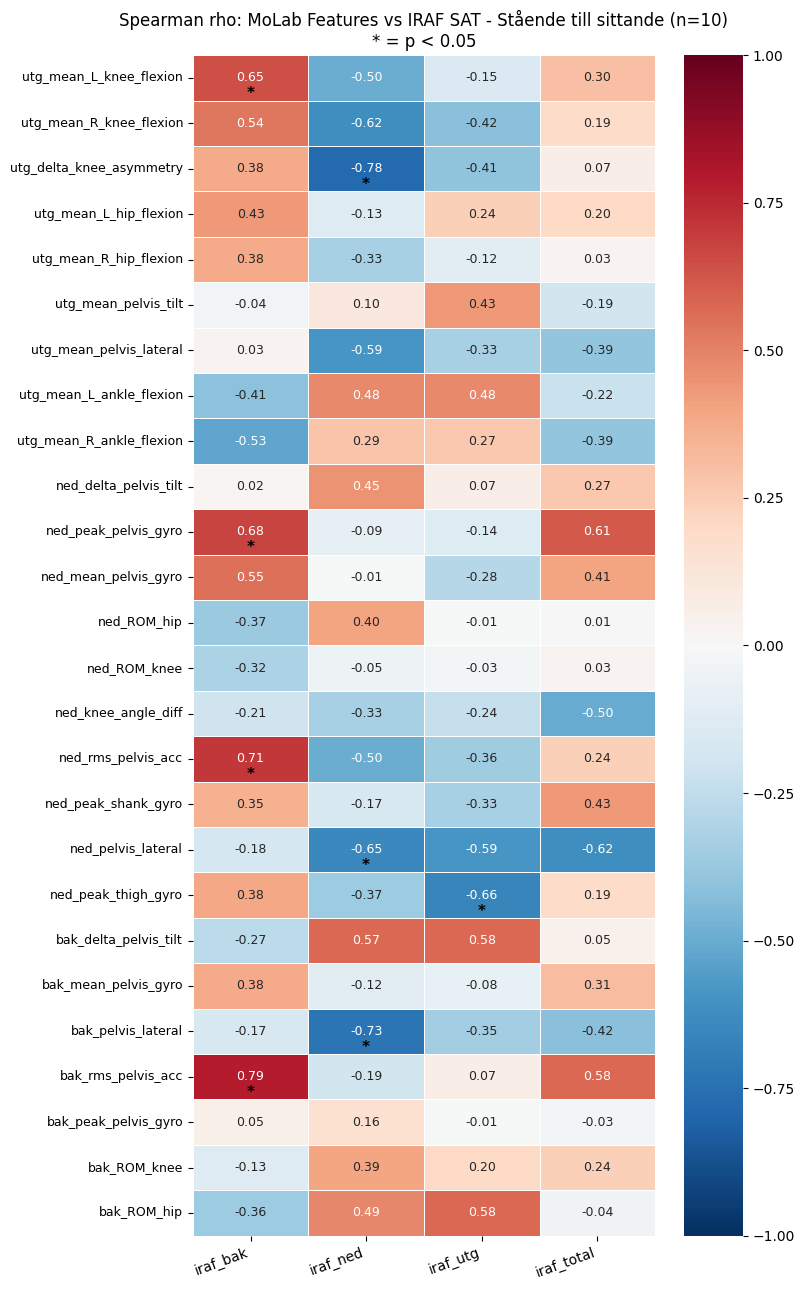

In [13]:
all_feats_d = feat_utg_d.merge(feat_ned_d, on='video', how='outer').merge(feat_bak_d, on='video', how='outer')
merged_all_d = all_feats_d.merge(iraf_pv_d, on='video')

feat_cols_d = [c for c in all_feats_d.columns if c != 'video']
iraf_cols_d = [c for c in iraf_pv_d.columns if c != 'video']

rho_mat_d = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
p_mat_d   = pd.DataFrame(index=feat_cols_d, columns=iraf_cols_d, dtype=float)
for fc in feat_cols_d:
    for ic in iraf_cols_d:
        vals = merged_all_d[[fc, ic]].dropna()
        if len(vals) >= 3:
            rho_mat_d.loc[fc, ic], p_mat_d.loc[fc, ic] = stats.spearmanr(vals[fc], vals[ic])

fig, ax = plt.subplots(figsize=(8, max(8, len(feat_cols_d) * 0.5)))
sns.heatmap(rho_mat_d.astype(float), annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, mask=rho_mat_d.isna(), annot_kws={'size': 9})
for i, fc in enumerate(feat_cols_d):
    for j, ic in enumerate(iraf_cols_d):
        if pd.notna(p_mat_d.loc[fc, ic]) and p_mat_d.loc[fc, ic] < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_title('Spearman rho: MoLab Features vs IRAF SAT - Stående till sittande (n=10)\n* = p < 0.05', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(DOWN_OUT_DIR_MOLAB + 'molab_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
corr_results_d = pd.DataFrame([
    {'feature': fc, 'iraf_score': ic, 'spearman_rho': rho_mat_d.loc[fc, ic], 'p_value': p_mat_d.loc[fc, ic]}
    for fc in feat_cols_d for ic in iraf_cols_d
    if pd.notna(rho_mat_d.loc[fc, ic])
]).sort_values('spearman_rho', key=abs, ascending=False)

corr_results_d.to_csv(DOWN_OUT_DIR_MOLAB + 'molab_correlation_results.csv', index=False)
print(f'{len(corr_results_d)} correlations saved')
corr_results_d.head(10)


104 correlations saved


,feature,iraf_score,spearman_rho,p_value
88,bak_rms_pelvis_acc,iraf_bak,0.786600,0.006950
9,utg_delta_knee_asymmetry,iraf_ned,-0.776791,0.008213
85,bak_pelvis_lateral,iraf_ned,-0.727859,0.017014
60,ned_rms_pelvis_acc,iraf_bak,0.707330,0.022143
40,ned_peak_pelvis_gyro,iraf_bak,0.676842,0.031587
74,ned_peak_thigh_gyro,iraf_utg,-0.660606,0.037588
69,ned_pelvis_lateral,iraf_ned,-0.648345,0.042600
0,utg_mean_L_knee_flexion,iraf_bak,0.646353,0.043454
71,ned_pelvis_lateral,iraf_total,-0.624242,0.053718
5,utg_mean_R_knee_flexion,iraf_ned,-0.623879,0.053898
